            Value
Month            
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121


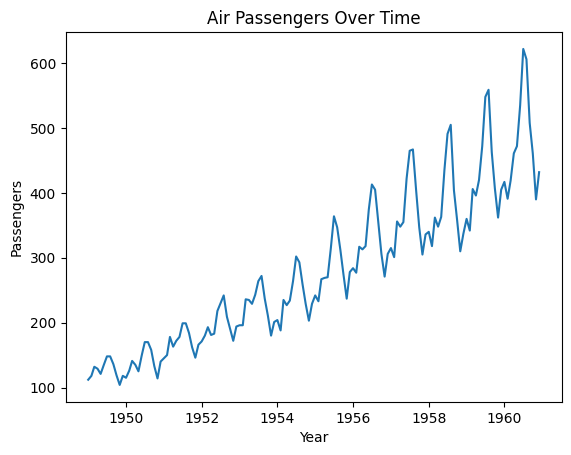

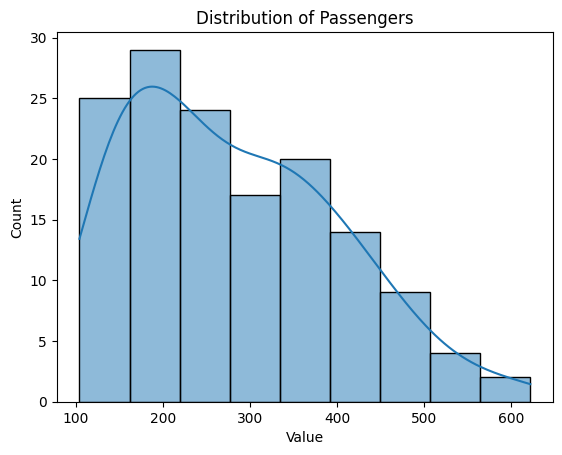

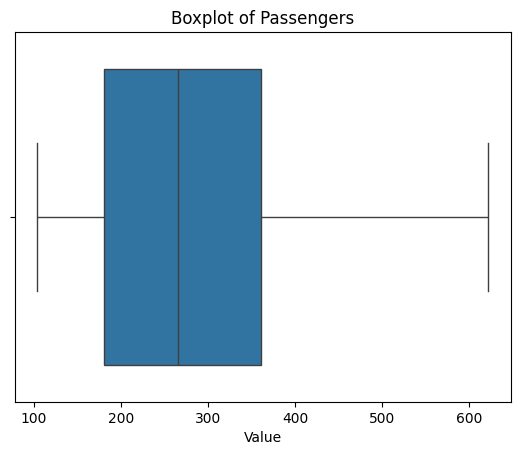

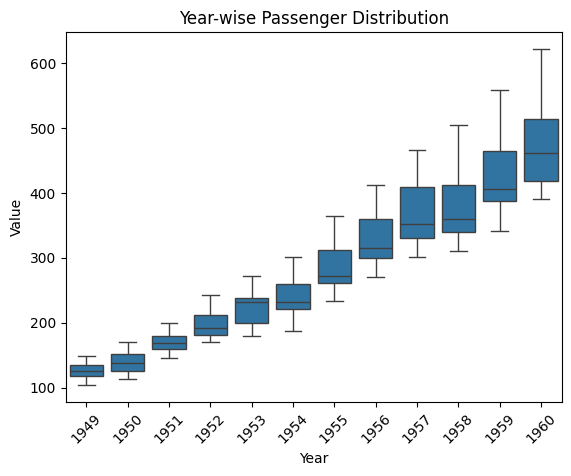

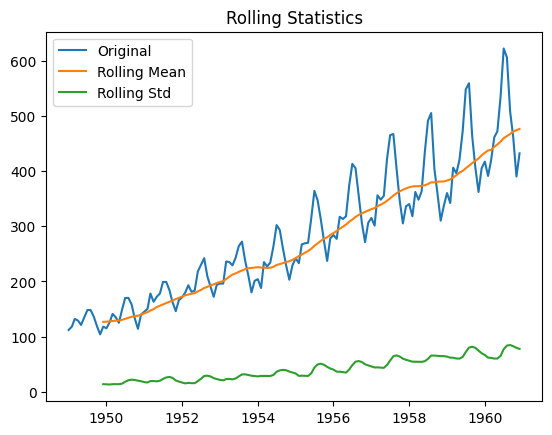

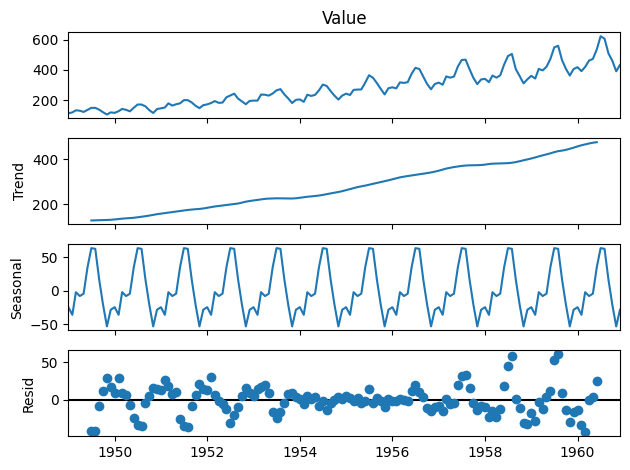

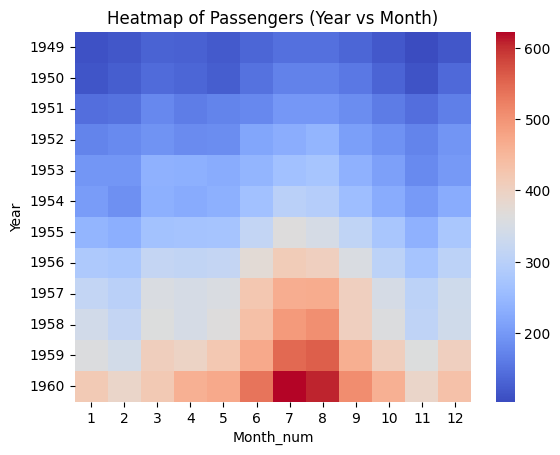

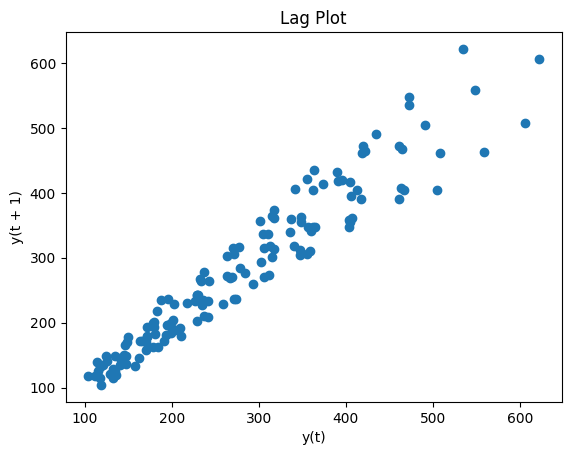

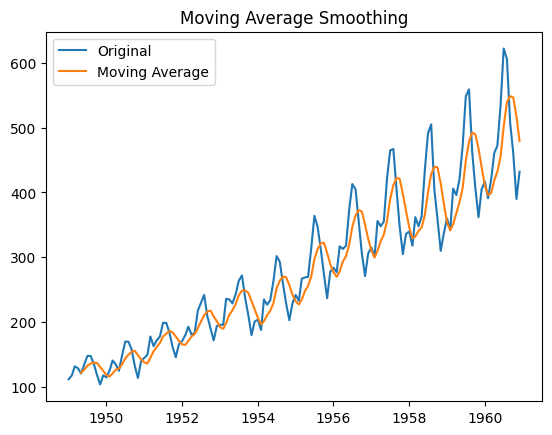

In [3]:
# =========================
# STEP 1: Install libraries
# =========================
!pip install seaborn statsmodels

# =========================
# STEP 2: Import libraries
# =========================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

# =========================
# STEP 3: Load dataset
# =========================
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)
df.rename(columns={'Passengers': 'Value'}, inplace=True)

print(df.head())

# =========================
# STEP 4: Basic Line Plot
# =========================
plt.figure()
plt.plot(df['Value'])
plt.title("Air Passengers Over Time")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.show()

# =========================
# STEP 5: Histogram (Distribution)
# =========================
plt.figure()
sns.histplot(df['Value'], kde=True)
plt.title("Distribution of Passengers")
plt.show()

# =========================
# STEP 6: Boxplot (Outliers)
# =========================
plt.figure()
sns.boxplot(x=df['Value'])
plt.title("Boxplot of Passengers")
plt.show()

# =========================
# STEP 7: Year-wise Boxplot
# =========================
df['Year'] = df.index.year

plt.figure()
sns.boxplot(x='Year', y='Value', data=df)
plt.xticks(rotation=45)
plt.title("Year-wise Passenger Distribution")
plt.show()

# =========================
# STEP 8: Rolling Statistics
# =========================
rolling_mean = df['Value'].rolling(window=12).mean()
rolling_std = df['Value'].rolling(window=12).std()

plt.figure()
plt.plot(df['Value'], label='Original')
plt.plot(rolling_mean, label='Rolling Mean')
plt.plot(rolling_std, label='Rolling Std')
plt.legend()
plt.title("Rolling Statistics")
plt.show()

# =========================
# STEP 9: Decomposition
# =========================
decomposition = seasonal_decompose(df['Value'], model='additive', period=12)
decomposition.plot()
plt.show()

# =========================
# STEP 10: Heatmap (Month vs Year)
# =========================
df['Month_num'] = df.index.month

pivot = df.pivot_table(values='Value', index='Year', columns='Month_num')

plt.figure()
sns.heatmap(pivot, cmap='coolwarm')
plt.title("Heatmap of Passengers (Year vs Month)")
plt.show()

# =========================
# STEP 11: Lag Plot (Trend check)
# =========================
from pandas.plotting import lag_plot

plt.figure()
lag_plot(df['Value'])
plt.title("Lag Plot")
plt.show()

# =========================
# STEP 12: Moving Average
# =========================
df['Moving_Avg'] = df['Value'].rolling(window=5).mean()

plt.figure()
plt.plot(df['Value'], label='Original')
plt.plot(df['Moving_Avg'], label='Moving Average')
plt.legend()
plt.title("Moving Average Smoothing")
plt.show()